In [3]:
# @title libraries, github repo, and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import seaborn as sns
import kagglehub
import sys
import os

# import public github repo into notebook file directory
!rm -rf /content/Architectural-Biases-in-Time-Series-Anomaly-Detection;
!git clone https://github.com/KirillVishnyakov/Architectural-Biases-in-Time-Series-Anomaly-Detection;
!git -C /content/Architectural-Biases-in-Time-Series-Anomaly-Detection log --oneline -1

root_dir = "/content/Architectural-Biases-in-Time-Series-Anomaly-Detection"
sys.path.append(root_dir)
from utils.evaluation_utils import evaluation_metrics_helper

# data set
path = kagglehub.dataset_download("patrickfleith/controlled-anomalies-time-series-dataset") + "/data.csv"

Cloning into 'Architectural-Biases-in-Time-Series-Anomaly-Detection'...
remote: Enumerating objects: 512, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 512 (delta 10), reused 47 (delta 8), pack-reused 455 (from 2)
Receiving objects: 100% (512/512), 178.51 MiB | 27.70 MiB/s, done.
Resolving deltas: 100% (243/243), done.
286886c (HEAD -> main, origin/main, origin/HEAD) refactoring, report checkpoint
Using Colab cache for faster access to the 'controlled-anomalies-time-series-dataset' dataset.


In [17]:
# @title Set seed for reproducibility
seed = 432
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Mapping Architectural Biases in Time Series Anomaly Detection

## Abstract

This project compares how different deep learning architectures behave in multivariate time series anomaly detection. An LSTM forecaster, LSTM autoencoder, and PatchTST-inspired transformer <br>
encoder are evaluated using a residual-based pipeline with k-nearest neighbors anomaly scoring. While all models achieve similar overall F1 scores, they exhibit different detection patterns<br>
across anomaly types. The reconstruction-based model perform worse on complex anomalies, while the forecasting-based models are more consistent. Between forecasting models, the transformer and LSTM <br>
achieve similar overall performance, but show different recall patterns across anomaly types. These differences indicate that architectural choices introduce biases in anomaly detection.

## Introduction
Anomaly detection in multivariate time series is challenging due to the presence of complex temporal patterns, cross-feature <br>
dependencies, and distribution shifts. While deep learning models have achieved strong performance on related tasks such as forecasting <br>
and reconstruction, it remains unclear how different architectural choices influence the types of anomalies that are detected. <br>
Many deep learning models have shown good performance on forecasting, reconstruction <br>
and downstream tasks such as anomaly detection. Instead of focusing on trying to achieve SOTA results, <br>
this project aims at comparing how different architectural choices influence the types of anomalies detected. <br>
The dataset for this task was carefully chosen because it satisfied key constraints: <br>
- varied labeled anomaly types
- huge, multivariate dataset <br>
- distribution shifts, and non-obvious cross correlations across features. <br>

Three models/techniques are proposed for this task, each ordered in terms of increasing complexity: <br>
- pure lstm forecaster
- lstm autoencoder
- patchTST inspired transformer encoder

## Related works

Transformer-based architectures have recently become a dominant approach for modeling sequential data. <br>
[*Attention Is All You Need*](https://arxiv.org/abs/1706.03762), introduced the transformer
architecture and sinusoidal positional encoding.<br>The transformer model in this project initially began as an implementation <br>
of the encoder part of that paper, and still uses their positional encoding across time module.

[*A Time Series is Worth 64 Words*](https://arxiv.org/abs/2211.14730) introduces the idea of representing<br>
time series as sequences of patches which connects this task to tokens in natural language processing.<br>
This mechanism is supposed to help transformers better capture local <br>
temporal patterns, and greatly reduce computation times. <br>
The transformer model in this project uses this patch-based representation as its input structure.

My dataset contains heavy cross correlated features, therefore the model ran into a problem where it would collapse every feature into patches<br>
and not learn these correlations, something that the previous paper didn't explore because they dealt with datasets with minimal or no feature correlations. <br>
The [*CT-PatchTST*](https://arxiv.org/html/2501.08620v1) model proposes combining patch-based representations with both temporal and channel (feature-wise) <br>
attention which allows the transformer to learn those correlations. This is basically the design I followed for the transformer architecture in this project.<br>
Attention is applied sequentially across features and across patches (in that order). It is extendable such that <br>
multiple of those attention blocks can be stacked.

Recurrent neural networks such as Long Short-Term Memory (LSTM)<br>
models remain a strong baseline for time series forecasting. Implementations, such as those described <br>
in [Machine Learning Mastery tutorials](https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/) demonstrate how LSTMs can be used for this task. <br>
That tutorial was used as a first baseline/sanity check, and the models were then customized and expanded on.<br>

For anomaly scoring, the idea in this project is borrowed from [this kaggle tutorial](https://www.kaggle.com/code/praxitelisk/anomaly-detection-techniques-summary/code#kNN---Distance-Based-Methods): each residual vector is compared to a reference residual <br>
space constructed from clean training data using k-nearest neighbors.


## Proposed Method and Experimental setup
### Training Setup

All models are trained on the first 1,000,000 samples of the dataset, which consist of clean (non-anomalous) data. <br>
This subset is split into 80% training and 20% validation. <br>
A test set wasn't used for the forecasting/reconstruction part because the goal of this step is to teach each model <br>
how to better separate clean vs anomalous segments. Those models are then used as baseline candidates that represent their architecture. <br>
I.E, they don't need to be exhaustively tuned.

Training is performed using the AdamW optimizer with learning rates ranging from 5e-4 to 1e-3. <br>
A warmup followed by cosine decay learning rate scheduler is used, where the number of warmup steps depends on the dataset size. <br>
Early stopping is applied with variable patience and minimum delta parameters. <br>
Mean Squared Error (MSE) is used as the training loss for both forecasting and reconstruction tasks.<br>

Models are trained on GPU using Kaggle, Colab, or Modal environments, with batch sizes ranging from 256 to 1024 depending on <br>
hardware constraints (P100, A100, H100/H200, B200). <br>
(see `/content/Architectural-Biases-in-Time-Series-Anomaly-Detection/notebooks/tuning/*.ipynb`) <br>
The best model weights are then stored in <br> `/content/Architectural-Biases-in-Time-Series-Anomaly-Detection/saved_model_weights/*pt or *pth`<br>



### Residual Space Construction
Once training is complete, each model is run in inference mode over the full clean `1,000,000` segment. For each input window, <br>
the model produces a prediction, and the residual is computed as the difference between the true and predicted values.

These residuals are flattened into vector representations, forming a residual space denoted as `R_train`, as illustrated in Fig. 1  <br> <br>
<img src="https://raw.githubusercontent.com/KirillVishnyakov/Architectural-Biases-in-Time-Series-Anomaly-Detection/main/images/image1.png" width="400"><br>
Fig_1
<br>

The residual vectors are then standardized using the mean and standard deviation computed over `R_train`. <br>
This normalized residual space serves as a reference distribution of normal behavior.
<br> <br>

### Anomaly Scoring

After constructing `R_train`, anomaly detection is performed on unseen data. The model is applied in inference mode to the next portion of the dataset <br>
`(4,000,000 samples)`, which contains anomalies. The first 50% of this segment is used for validation.<br>
The choice of the split was influenced by distribution shift in the data over time. This 50% cutoff is the best slice I found that represented <br>
an equal split of anomalies (per category), and comparable means and variances across features.

For each input window, a residual vector is computed and normalized using the statistics of `R_train`. <br>
This residual is then compared to all elements in `R_train` using a k-nearest neighbors (k-NN) approach. <br>
The k parameter was set to `7` because of computational constraints.

The `anomaly score` is defined as the mean squared Euclidean distance to the k closest residuals in `R_train`, as illustrated in Fig. 2.<br>
<br><br>
<img src="https://raw.githubusercontent.com/KirillVishnyakov/Architectural-Biases-in-Time-Series-Anomaly-Detection/main/images/image2.png" width="500"><br>
Fig_2
<br> <br>
An `anomaly_score` represents "how anomalous" the current window is. <br>
The scoring functions are stored in <br> `/content/Architectural-Biases-in-Time-Series-Anomaly-Detection/utils/residual_scoring.py` <br>
A jupyter notebook<br> `/content/Architectural-Biases-in-Time-Series-Anomaly-Detection/notebooks/scoring_residuals.ipynb` has already computed all the anomaly scores which are stored in<br> `/content/Architectural-Biases-in-Time-Series-Anomaly-Detection/saved_model_scores/*.npz`


#### Evaluation

Time points were labeled as anomalies if their `anomaly_scores` exceeded the threshold `t`. <br>
The threshold `t` was set to the `100 - 1.5 = 98.5th` percentile of `anomaly_scores`.<br>

A smoothing window was applied over the anomaly scores. <br>
The size of the smoothing window was determined over a grid search on the validation dataset.<br>
The metrics of comparison were F1/recall/precision. <br> <br>

### Model architectures
#### LSTM Forecaster

The pure lstm forecaster takes in an input window and passes it through <br>
a Long Short-Term Memory (LSTM) neural network. Then uses a linear layer to project back into input space. <br><br>
<img src="https://raw.githubusercontent.com/KirillVishnyakov/Architectural-Biases-in-Time-Series-Anomaly-Detection/main/images/lstm_f.png" width="600"><br>
Fig.3 lstm forecaster diagram<br> <br>

#### LSTM Autoencoder

The lstm encoder-decoder takes in an input window passes it through an encoder similar to the previous model, <br>
but returns a tuple containing a tensor `out` representing the encoded input at each time step, <br>
the final hidden and final cell states `h0`, `c0`, and the input `x` itself used for teacher forcing during training. <br><br>
In order to vectorize the teacher forcing part, the `x` tensor is shifted to the right along the `L` dimension, <br>
and the first element along that dimension is replaced by 0 (or zero tensor if L > 1). <br>
The `out` and `x` tensors are then concatenated along the last dimension to give the lstm layer <br>
a combined representation of the previous true timestep + previous encoders output at that timestep.<br>
The combined representation and `(h0, c0)` are then fed into the decoder. <br><br>
<img src="https://raw.githubusercontent.com/KirillVishnyakov/Architectural-Biases-in-Time-Series-Anomaly-Detection/main/images/lstm_ae_train.png" width="600"><br>
Fig.4, lstm autoencoder diagram during training phase when teacher forcing is enabled <br>

During inference, and when scheduled sampling is applied, teacher forcing is no longer used. Instead of using the ground truth sequence, <br>
the decoder used autoregression: its own previous prediction is fed back as input for the next step at each timestep.

#### PatchTST Forecaster (Transformer Encoder)

Input sequences are split into overlapping patches per feature and projected into an embedding space. <br>
Positional encodings and learnable feature embeddings are added before passing through stacked attention blocks. <br>
Each block applies feature-wise attention and patch-wise attention sequentially. <br>
The resulting representations are flattened and mapped to the forecast horizon through a linear layer<br><br>
<img src="https://raw.githubusercontent.com/KirillVishnyakov/Architectural-Biases-in-Time-Series-Anomaly-Detection/main/images/patch_tst.png" width="600"><br>
Fig.5 [(Huo et al., 2025)](https://arxiv.org/html/2501.08620v1) Patch_TST diagram
<br><br>

All models are stored in <br>`/content/Architectural-Biases-in-Time-Series-Anomaly-Detection/models/*.py`

### Preprocessing

All features are normalized using a RobustScaler fit on the training data<br>
and applied consistently across validation and test splits.<br>

The time series is segmented using sliding windows, with a lookback window<br>
ranging from 100 to 256 depending on the model, and a forecast horizon of 4<br>
for forecasting-based models.<br>

Model errors are represented as residual vectors obtained by flattening the<br>
difference between predictions and targets.

Reversible Instance Normalization [(RevIN)](https://github.com/ts-kim/RevIN) is applied  
at each models input and output to mitigate distribution shifts.

## Results

### Final Model Parameters

| Model                  | Lookback | Horizon | Hidden / d_model | Layers / Blocks | Other Params                  | LR      | Batch | Epochs | best MSE loss |
|----------------------|----------|---------|------------------|------------------|-------------------------------|---------|-------|--------|--------|
| LSTM Autoencoder     | 256      | –       | EDR = 0.55       | (hardcoded)*     | Latent scaling via EDR        | 0.00225 | 512   | 15     | 0.0014 |
| LSTM Forecaster      | 100      | 4       | 128              | 1 layer          | –                             | 0.001   | 128   | 50     | 0.0209 |
| PatchTST Forecaster  | 256      | 4       | 256              | 1 block          | 8 heads, dropout = 0.0        | 0.001   | 512   | 10     | 0.0200 |

These models weren't finetuned to the max because of computational constraints, and because <br>
good forecasting/reconstruction losses don't always translate to good anomaly detectors. <br>

The objective was to train baseline models across different but comparable architectures. <br>
Therefore, some hyperparameters were selected using practical heuristics rather than <br>
exhaustive search. For example, the lookback window was chosen to be large enough to capture <br>
temporal shifts in the data while remaining computationally tractable and edr was chosen small enough to not inflate MSE loss and end up with poor reconstruction.<br><br>

*(hardcoded), there is one encoder layer and one decoder layer in the AutoEncoder model

#### load residual metrics

In [6]:
def create_dict(name):
    path = os.path.join(root_dir, "saved_model_scores", name)
    with np.load(path) as data:
       results = {name: metric for name, metric in data.items()}
    return results

def load_scores(results):
    return (
        (results["v_scores"],
        results["v_labels"],
        results["v_categories"]),
        (results["t_scores"],
        results["t_labels"],
        results["t_categories"])
    )

In [7]:
lstm_f_results = create_dict("lstm_f_results.npz")
lstm_ae_results = create_dict("lstm_ae_results.npz")
transformer_f_results = create_dict("transformer_f_results.npz")

In [8]:
lstm_f_val_metrics, lstm_f_test_metrics = \
    load_scores(lstm_f_results)
transformer_val_metrics, transformer_test_metrics = \
    load_scores(transformer_f_results)
ae_val_metrics, ae_test_metrics = \
    load_scores(lstm_ae_results)

#### Tuning Smoothing window over the anomaly scores computed on the validation dataset

In [9]:
def tune_smoothing_window(scores, labels, cats, name="None"):
    results = []

    for window in window_grid:
        F1, precision, _ = evaluation_metrics_helper(scores, labels, cats, window)
        results.append({
            "model_name": name,
            "F1": round(F1.item(), 2),
            "smoothing_window": window
        })

    results.sort(key=lambda x: x['F1'], reverse=True)
    return pd.Series(results[0])

In [10]:
window_grid = np.linspace(1, 1000, 20).astype(int)

pd.DataFrame(
    [tune_smoothing_window(*lstm_f_val_metrics, "lstm"),
    tune_smoothing_window(*transformer_val_metrics, "transformer"),
    tune_smoothing_window(*ae_val_metrics, "LSTM AutoEncoder")]
)

,model_name,F1,smoothing_window
0,lstm,0.61,474
1,transformer,0.64,316
2,LSTM AutoEncoder,0.58,526


#### Compute F1 on the anomaly scores computed on the test set with the best smoothing windows

In [11]:
def category_summary(scores, labels, cats, window, name):
    series = []
    F1, precision, cat_dict = evaluation_metrics_helper(scores, labels, cats, window)
    cat_dict["Precision"] = np.round(precision, 3)
    cat_dict["F1"] = np.round(F1, 3)

    series.append(pd.Series(cat_dict, name = name))
    return pd.concat(series, axis=1).T

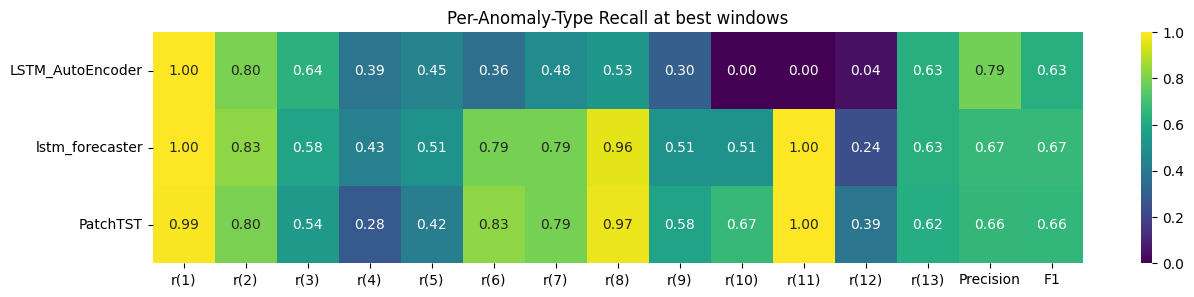

In [12]:
lstm_autoencoder_series = category_summary(*ae_test_metrics, 526, "LSTM_AutoEncoder")
lstm_forecaster_series = category_summary(*lstm_f_test_metrics, 474, "lstm_forecaster")
patchTST_series = category_summary(*transformer_test_metrics, 316, "PatchTST")
category_df = pd.concat([lstm_autoencoder_series, lstm_forecaster_series, patchTST_series])

cols = [c for c in category_df.columns if ("r" in c or "F1" in c)]
plt.figure(figsize=(15, 3))
sns.heatmap(category_df[cols], annot=True, fmt=".2f", cmap="viridis")
plt.title("Per-Anomaly-Type Recall at best windows")
plt.show()

All models achieve comparable overall performance, with the LSTM Forecaster (F1 = 0.67) and PatchTST (F1 = 0.66) slightly outperforming the LSTM Autoencoder (F1 = 0.64). <br><br>
The LSTM Autoencoder has the best precision and completely misses categories 10, 11, 12. <br><br>
Comparing the transformer-based PatchTST with the LSTM Forecaster, the former <br>
performs better on anomalies 6, 10, and 12, while the latter <br>
achieves higher recall on categories 4 and 5. <br><br>
These results indicate that despite similar F1, <br>
architectural choices do influence the types of anomalies each model is best suited to detect.

#### Analyze the same Per Anomaly Recall but this time, set smoothing window to 1.

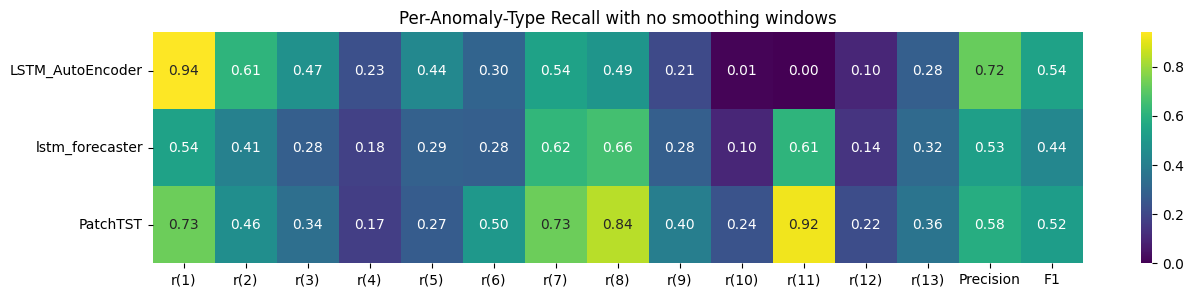

In [13]:
lstm_autoencoder_series = category_summary(*ae_test_metrics, 1, "LSTM_AutoEncoder")
lstm_forecaster_series = category_summary(*lstm_f_test_metrics, 1, "lstm_forecaster")
patchTST_series = category_summary(*transformer_test_metrics, 1, "PatchTST")
category_df = pd.concat([lstm_autoencoder_series, lstm_forecaster_series, patchTST_series])

cols = [c for c in category_df.columns if ("r" in c or "F1" in c)]
plt.figure(figsize=(15, 3))
sns.heatmap(category_df[cols], annot=True, fmt=".2f", cmap="viridis")
plt.title("Per-Anomaly-Type Recall with no smoothing windows")
plt.show()

The same heatmap but without smoothing windows, indicates that the lstm_forecaster benefits significantly from smoothing windows. <br>
In contrast to the patchTST that has comparable recall metrics (moderately worse) without relying as heavily on smoothing. <br>
Additionally, the optimal smoothing window for the LSTM Forecaster `526` is substantially larger than that of the transformer `316`, implying that the former model <br>
produces noisier or more locally unstable anomaly scores, while the latter appears to generate more stable scores requiring less pre-processing.<br>

## Conclusion

This project explored how different deep learning architectures behave in a multivariate time series anomaly detection setting. While all models achieved comparable overall F1 scores, <br>
the different architectures did have biases when it came to detecting different types of anomalies. The LSTM autoencoder struggled massively in recalling some anomalies that other models did well on. <br>
There is a clear bias between the two approaches (reconstruction and forecasting based) when it comes to detecting anomalies.

When comparing the two forecasting models (lstm and transformer encoder), results suggest that even within the same forecasting-based approach, <br>
architectural differences such as attention vs recurrence lead to different detection behaviors. <br>

Additionally, the use of smoothing windows played a significant role in performance, especially for the LSTM-based models, suggesting that some architectures produce noisier anomaly scores that require post-processing.<br>

Overall, this highlights that architectural choices introduce biases in anomaly detection. Even when models achieve similar F1 scores, <br>
they may behave very differently depending on the type of anomaly.<br>

Future work could focus more on the anomaly scoring part, tune each model more seriously, and extend the transformer encoder to work like a transformer encoder decoder as seen here [*Sentinel*](https://arxiv.org/html/2503.17658v1).